In [1]:
import sys
!{sys.executable} -m pip install scikit-learn imbalanced-learn xgboost scikit-image pillow matplotlib seaborn scipy
#hello world

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray, rgb2hsv
from skimage import img_as_ubyte

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score)
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

import xgboost as xgb

In [4]:
import os

# Images are inside ham_images folder
IMG_DIRS = [
    "ham_images/HAM10000_images_part_1",
    "ham_images/HAM10000_images_part_2"
]

for folder in IMG_DIRS:
    count = len([f for f in os.listdir(folder) if f.endswith(".jpg")])
    print(f"✅ {folder}: {count} images")

✅ ham_images/HAM10000_images_part_1: 5000 images
✅ ham_images/HAM10000_images_part_2: 4507 images


In [5]:
DATA_DIR  = "."
META_CSV  = "ham_images/HAM10000_metadata.csv"

IMG_DIRS = [
    "ham_images/HAM10000_images_part_1",
    "ham_images/HAM10000_images_part_2"
]

IMG_SIZE    = (128, 128)
RANDOM_SEED = 42

In [6]:
import os
print(os.listdir())

['.git', '.gitignore', 'data_preprocess_eda.ipynb', 'eda.ipynb', 'ham_images', 'README.md', 'scaler.pkl', 'svm_model.pkl', 'xgb_model.pkl']


In [7]:
import cv2

def load_image(image_id):
    img_name = image_id + ".jpg"
    
    for d in IMG_DIRS:
        path = os.path.join(d, img_name)
        if os.path.exists(path):
            return cv2.imread(path)
    
    return None

In [8]:
import pandas as pd

df = pd.read_csv(META_CSV)

img = load_image(df.iloc[0]['image_id'])

print(img.shape)

(450, 600, 3)


In [9]:
# 1.  LABEL MAP
# ─────────────────────────────────────────────
LABEL_MAP = {
    "mel":  "Melanoma",
    "bcc":  "Basal Cell Carcinoma",
    "akiec":"Actinic Keratoses",
    "bkl":  "Benign Keratosis",
    "df":   "Dermatofibroma",
    "nv":   "Melanocytic Nevi",
    "vasc": "Vascular Lesions",
}

In [10]:
# ── Stage 2: Dataset Overview ─────────────────────────────────────────────
df = pd.read_csv(META_CSV)
df['label_name'] = df['dx'].map(LABEL_MAP)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total records      : {len(df)}")
print(f"Unique lesion IDs  : {df['lesion_id'].nunique()}")
print(f"Unique image IDs   : {df['image_id'].nunique()}")
print(f"Number of columns  : {df.shape[1]}")
print(f"\nColumn names       : {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")
print(f"\nClass distribution:\n{df['label_name'].value_counts()}")
print(f"\nSex distribution:\n{df['sex'].value_counts()}")
print(f"\nLocalization distribution:\n{df['localization'].value_counts()}")
print(f"\nDiagnosis confirmation methods:\n{df['dx_type'].value_counts()}")

# Verify all images are findable
def get_image_path(image_id):
    for d in IMG_DIRS:
        path = os.path.join(d, image_id + ".jpg")
        if os.path.exists(path):
            return path
    return None

df['img_path'] = df['image_id'].apply(get_image_path)
missing = df['img_path'].isna().sum()
print(f"\nMissing images     : {missing}")
df = df[df['img_path'].notna()].reset_index(drop=True)
print(f"Usable records     : {len(df)}")


DATASET OVERVIEW
Total records      : 10015
Unique lesion IDs  : 7470
Unique image IDs   : 10015
Number of columns  : 8

Column names       : ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'label_name']

Data types:
lesion_id           str
image_id            str
dx                  str
dx_type             str
age             float64
sex                 str
localization        str
label_name          str
dtype: object

Missing values per column:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
label_name       0
dtype: int64

Class distribution:
label_name
Melanocytic Nevi        6705
Melanoma                1113
Benign Keratosis        1099
Basal Cell Carcinoma     514
Actinic Keratoses        327
Vascular Lesions         142
Dermatofibroma           115
Name: count, dtype: int64

Sex distribution:
sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64



Saved 10015 preprocessed images → processed_images.npy

PREPROCESSING VALIDATION
Image array shape  : (10015, 128, 128, 3)   (N, H, W, C)
Data type (stored) : uint8  — uint8 saves memory
Pixel value range  : [0, 255] → normalized [0.0, 1.0] per image during feature extraction
Sample pixel mean  : 0.7641
Sample pixel std   : 0.0795
Per-channel means  : R=0.8393  G=0.6803  B=0.7727


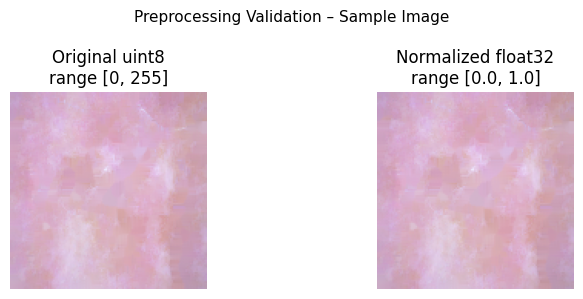

Validation plot saved → preprocessing_validation.png


In [11]:
# ── Stage 3: Preprocessing Pipeline ───────────────────────────────────────
import cv2

def preprocess_image(img_path, size=IMG_SIZE):
    """Load, resize, convert BGR→RGB."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def remove_hair(img):
    """Inpainting-based hair removal."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    cleaned = cv2.inpaint(img, mask, inpaintRadius=1, flags=cv2.INPAINT_TELEA)
    return cleaned

PROCESSED_NPY = "processed_images.npy"
PROCESSED_IDS = "processed_ids.npy"

if not os.path.exists(PROCESSED_NPY):
    images_raw, ids = [], []
    for _, row in df.iterrows():
        img = preprocess_image(row['img_path'])
        if img is not None:
            img = remove_hair(img)
            images_raw.append(img)
            ids.append(row['image_id'])
    images_uint8 = np.array(images_raw, dtype=np.uint8)
    np.save(PROCESSED_NPY, images_uint8)
    np.save(PROCESSED_IDS, np.array(ids))
    print(f"Saved {len(images_uint8)} preprocessed images → {PROCESSED_NPY}")
else:
    images_uint8 = np.load(PROCESSED_NPY)
    ids = np.load(PROCESSED_IDS)
    print(f"Loaded {len(images_uint8)} preprocessed images from cache")

# Align df to saved order
id_to_idx = {iid: i for i, iid in enumerate(ids)}
df = df[df['image_id'].isin(id_to_idx)].copy()
df['proc_idx'] = df['image_id'].map(id_to_idx)
df = df.sort_values('proc_idx').reset_index(drop=True)
images_uint8 = images_uint8[df['proc_idx'].values]

# ── Validation Output (normalize only 1 sample, not all 10015) ────────────
sample = images_uint8[0]
sample_float = sample.astype(np.float32) / 255.0

print("\n" + "=" * 60)
print("PREPROCESSING VALIDATION")
print("=" * 60)
print(f"Image array shape  : {images_uint8.shape}   (N, H, W, C)")
print(f"Data type (stored) : {images_uint8.dtype}  — uint8 saves memory")
print(f"Pixel value range  : [0, 255] → normalized [0.0, 1.0] per image during feature extraction")
print(f"Sample pixel mean  : {sample_float.mean():.4f}")
print(f"Sample pixel std   : {sample_float.std():.4f}")
print(f"Per-channel means  : R={sample_float[:,:,0].mean():.4f}  "
      f"G={sample_float[:,:,1].mean():.4f}  B={sample_float[:,:,2].mean():.4f}")

# Free memory — uint8 array stays, float32 sample discarded
del sample_float

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(images_uint8[0])
axes[0].set_title("Original uint8\nrange [0, 255]")
axes[0].axis('off')
axes[1].imshow(images_uint8[0].astype(np.float32) / 255.0)
axes[1].set_title("Normalized float32\nrange [0.0, 1.0]")
axes[1].axis('off')
plt.suptitle("Preprocessing Validation – Sample Image", fontsize=11)
plt.tight_layout()
plt.savefig("preprocessing_validation.png", dpi=150)
plt.show()
print("Validation plot saved → preprocessing_validation.png")

# images_uint8 is your main image array going forward
# Normalization happens per-image inside feature extraction functions
images = images_uint8  # keep this name consistent with rest of notebook